In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [47]:
df = pd.read_csv('data.csv',encoding='latin-1')

In [48]:
df.shape

(541909, 8)

In [49]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
138666,548203,21790,VINTAGE SNAP CARDS,76,3/29/2011 16:41,1.95,NaN,United Kingdom
187347,552963,85152,HAND OVER THE CHOCOLATE SIGN,5,5/12/2011 12:57,2.10,16743.0,United Kingdom
435177,574074,22568,FELTCRAFT CUSHION OWL,2,11/2/2011 15:33,7.46,NaN,United Kingdom
304316,563569,23200,JUMBO BAG PEARS,10,8/17/2011 14:47,2.08,18257.0,United Kingdom
504216,578944,23322,LARGE WHITE HEART OF WICKER,1,11/27/2011 13:41,2.95,16005.0,United Kingdom


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


### Data Assessment Summay:

  This dataset contains transactional data from an online retail store. Each row represents a product purchased within a customer invoice, including product information, quantity, pricing, customer ID, purchase date, and customer country. The dataset is useful for sales analysis, customer behavior analysis, product recommendation systems, and business intelligence tasks.

#### Column Descriptions:

- InvoiceNo	: Unique invoice/order number for a transaction
- StockCode	: Unique product/item code
- Description :	Name/description of the product
- Quantity:	Number of units purchased
- InvoiceDate :	Date and time of purchase
- UnitPrice :	Price of one product unit
- CustomerID :	Unique ID assigned to each customer
- Country :	Country where the customer belongs

#### Additional Information:
 - Same invoice number may appear multiple times because one order can contain many products.
 - If invoice starts with "C" it often means:
        - Cancelled order
        - Returned transaction

- Quantity has negative numbers ,which means:
        - Returned item
        - Cancelled purchase

### Dirty data:
- Invoice data should be in the date-time format(validity)
- missing values in customer-id(completeness)
- description column also has missing data(completeness)
- 
### Messy Data:
- this data has no structural issues


In [51]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(5268)

In [53]:
duplicates = df[df.duplicated()]
duplicates.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [54]:
# it has duplicates beacuse same customer has ordered different products at the same time

In [55]:
# Convert datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [56]:
# Filling missing values with 'unknown'in customer-id
df['CustomerID'] = df['CustomerID'].fillna('Unknown')

In [57]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
                                      ... 
LETTER "U" BLING KEY RING                1
wet                                      1
wet boxes                                1
????damages????                          1
lost                                     1
Name: count, Length: 4223, dtype: int64

In [58]:
# 1. Clean text
df['Description'] = df['Description'].str.strip().str.upper()

# 2. Remove junk descriptions
df = df[~df['Description'].str.contains('DAMAGES|LOST|WET|\?', na=False)]



<>:5: SyntaxWarning: "\?" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\?"? A raw string is also an option.
<>:5: SyntaxWarning: "\?" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\?"? A raw string is also an option.
C:\Users\tooba\AppData\Local\Temp\ipykernel_15732\322754984.py:5: SyntaxWarning: "\?" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\?"? A raw string is also an option.
  df = df[~df['Description'].str.contains('DAMAGES|LOST|WET|\?', na=False)]


In [59]:
def safe_mode(x):
    # Remove NaN values
    x = x.dropna()
    
    # If group becomes empty
    if len(x) == 0:
        return None
    
    # Get mode
    m = x.mode()
    
    # If mode is empty
    if len(m) == 0:
        return None
    
    return m.iloc[0]

mapping = df.groupby('StockCode')['Description'].agg(safe_mode)

In [60]:
df['Description'] = df['Description'].fillna(
    df['StockCode'].map(mapping)
)

In [61]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
38109,539492,22602,CHRISTMAS RETROSPOT HEART WOOD,2,2010-12-20 10:14:00,1.66,Unknown,United Kingdom
48855,540478,20711,JUMBO BAG TOYS,200,2011-01-07 14:53:00,1.65,15769.0,United Kingdom
463725,576070,23351,ROLL WRAP 50'S CHRISTMAS,2,2011-11-13 15:58:00,1.25,13451.0,United Kingdom
541351,581498,21329,DINOSAURS WRITING SET,1,2011-12-09 10:26:00,3.29,Unknown,United Kingdom
94799,C544413,22364,GLASS JAR DIGESTIVE BISCUITS,-6,2011-02-18 14:36:00,2.95,14760.0,United Kingdom


In [62]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2369
REGENCY CAKESTAND 3 TIER               2200
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1727
LUNCH BAG RED RETROSPOT                1638
                                       ... 
CROCHET LILAC/RED BEAR KEYRING            1
LARGE HEART FLOWERS HOOK                  1
SET 10 CARDS SNOWY ROBIN 17099            1
SET 10 CARDS SWIRLY XMAS TREE 17104       1
LETTER "U" BLING KEY RING                 1
Name: count, Length: 4153, dtype: int64

In [63]:
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,541756.000000,541756,541756.000000
mean,9.609396,2011-07-04 13:24:04.103544,4.612416
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,217.886966,NaN,96.773484


In [64]:
df.isnull().sum()

InvoiceNo        0
StockCode        0
Description    112
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID       0
Country          0
dtype: int64

In [65]:
missing_desc = df[df['Description'].isna()]

missing_desc[['StockCode', 'Description']].head()

,StockCode,Description
1970,21134,NaN
1987,85226A,NaN
1988,85044,NaN
2024,20950,NaN
2026,84670,NaN


In [66]:
missing_desc['StockCode'].nunique()

112

In [67]:
df = df.dropna(subset=['Description'])

In [ ]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [69]:
df = df.drop_duplicates()

In [70]:
print(df.duplicated().sum())

0


In [71]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [72]:
df[df['Quantity'] > 10000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [73]:
clean_df = df.copy()

# Remove cancelled invoices
df = df[
    ~df['InvoiceNo'].str.startswith('C', na=False)
]

# Remove invalid quantity
df = df[clean_df['Quantity'] > 0]

# Remove invalid prices
df = clean_df[clean_df['UnitPrice'] > 0]

C:\Users\tooba\AppData\Local\Temp\ipykernel_15732\917791775.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[clean_df['Quantity'] > 0]


In [74]:
clean_df.describe()

,Quantity,InvoiceDate,UnitPrice
count,536376.000000,536376,536376.000000
mean,9.681488,2011-07-04 09:18:09.081838,4.634944
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 10:52:00,1.250000
50%,3.000000,2011-07-19 14:29:00,2.080000
75%,10.000000,2011-10-18 17:05:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.957860,NaN,97.257080


 - Cancelled transactions, negative quantities, and invalid pricing entries were excluded from the    primary analytical dataset to ensure accurate sales, revenue, and customer behavior analysis. However, these records may still provide value for return and operational analysis in future business studies

#### Phase 2 — Feature Engineering

In [75]:
# Calculating total revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [76]:
# date based features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.month_name()
df['Day'] = df['InvoiceDate'].dt.day
df['DayName'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour
df['Quarter'] = df['InvoiceDate'].dt.quarter

In [77]:
# Weekend vs Weekday
df['IsWeekend'] = df['DayName'].isin(['Saturday', 'Sunday'])

In [78]:
# Basket size per invoice
basket_size = df.groupby('InvoiceNo')['Quantity'].sum()

df['BasketSize'] = df['InvoiceNo'].map(basket_size)


In [79]:
# Number of Unique Products per Invoice
unique_products = df.groupby('InvoiceNo')['StockCode'].nunique()

df['UniqueProducts'] = df['InvoiceNo'].map(unique_products)

In [103]:
# Customer Total Spending
customer_spending = df.groupby('CustomerID')['Revenue'].sum()

df['CustomerSpending'] = df['CustomerID'].map(customer_spending)

In [104]:
# Invoice Value
invoice_value = df.groupby('InvoiceNo')['Revenue'].sum()

df['InvoiceValue'] = df['InvoiceNo'].map(invoice_value)

#### EDA 

In [ ]:
# Sales Analysis
total_revenue = df['Revenue'].sum()
total_revenue

np.float64(9726006.954)

In [ ]:
#  Average Order Value (AOV)
order_revenue = df.groupby('InvoiceNo')['Revenue'].sum()
aov = order_revenue.mean()
aov

np.float64(399.19581981612214)

In [105]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    8189252.304
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

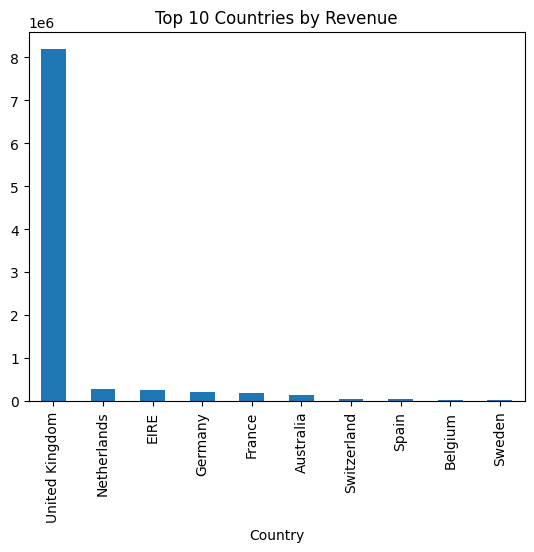

In [106]:
country_sales.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.show()

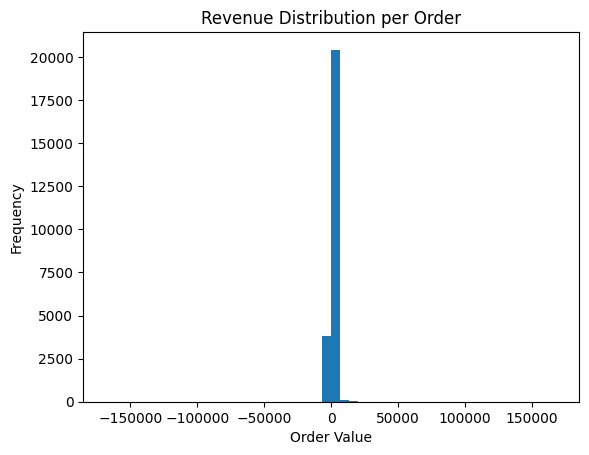

In [81]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(order_revenue, bins=50)
plt.title("Revenue Distribution per Order")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

In [83]:

# Product Analysis
#Top-Selling Products (by quantity)
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47256
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35294
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26095
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

In [84]:
# Most Profitable Products
top_profit_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_profit_products


Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: Revenue, dtype: float64

In [85]:
# . Product Frequency (how often sold)
product_frequency = df['Description'].value_counts().head(10)
product_frequency

Description
WHITE HANGING HEART T-LIGHT HOLDER    2353
REGENCY CAKESTAND 3 TIER              2187
JUMBO BAG RED RETROSPOT               2153
PARTY BUNTING                         1719
LUNCH BAG RED RETROSPOT               1625
ASSORTED COLOUR BIRD ORNAMENT         1488
SET OF 3 CAKE TINS PANTRY DESIGN      1465
PACK OF 72 RETROSPOT CAKE CASES       1367
LUNCH BAG  BLACK SKULL.               1323
NATURAL SLATE HEART CHALKBOARD        1272
Name: count, dtype: int64

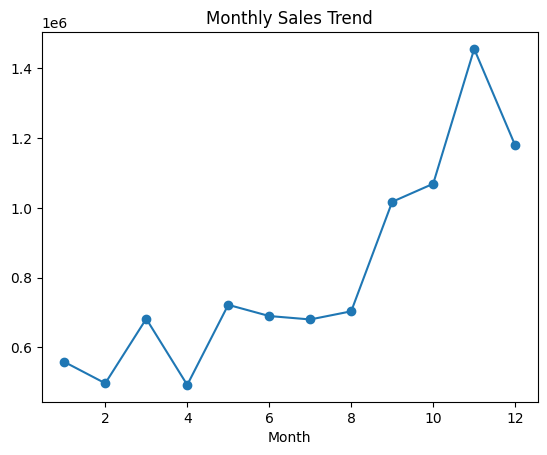

In [86]:
# Time-Series Analysis
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

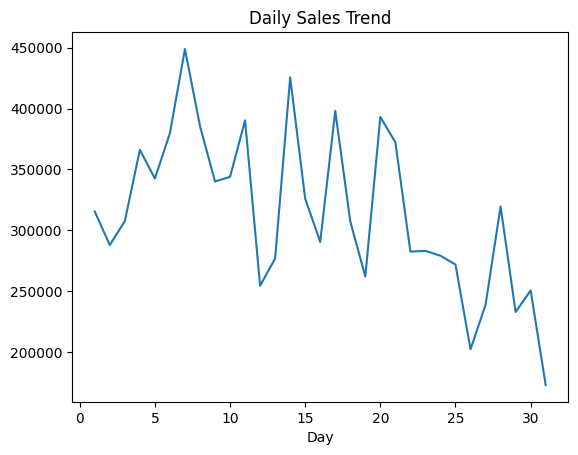

In [87]:
# daily trend
daily_sales = df.groupby('Day')['Revenue'].sum()

daily_sales.plot()
plt.title("Daily Sales Trend")
plt.show()

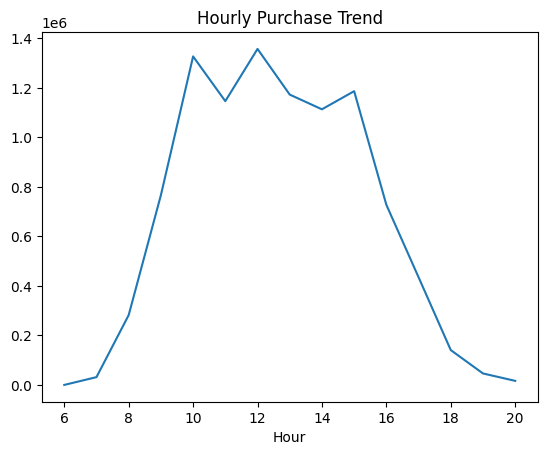

In [88]:
# hourly trend
hourly_sales = df.groupby('Hour')['Revenue'].sum()

hourly_sales.plot(kind='line')
plt.title("Hourly Purchase Trend")
plt.show()

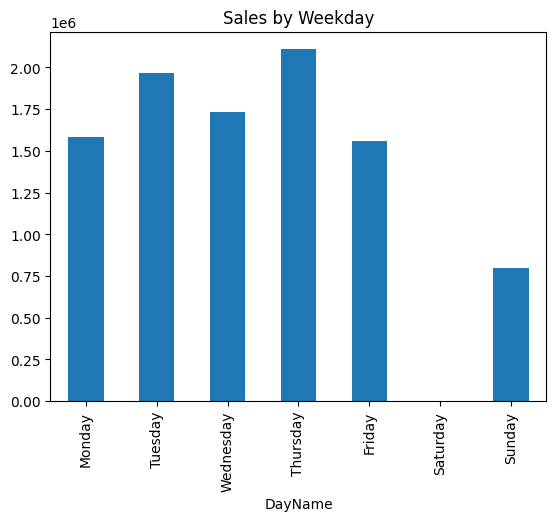

In [92]:
# weekday trends
weekday_sales = df.groupby('DayName')['Revenue'].sum()

weekday_sales = weekday_sales.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

weekday_sales.plot(kind='bar')
plt.title("Sales by Weekday")
plt.show()

In [93]:
# Correlation / Relationsh
df[['Quantity', 'Revenue']].corr()

,Quantity,Revenue
Quantity,1.00000,0.90115
Revenue,0.90115,1.00000


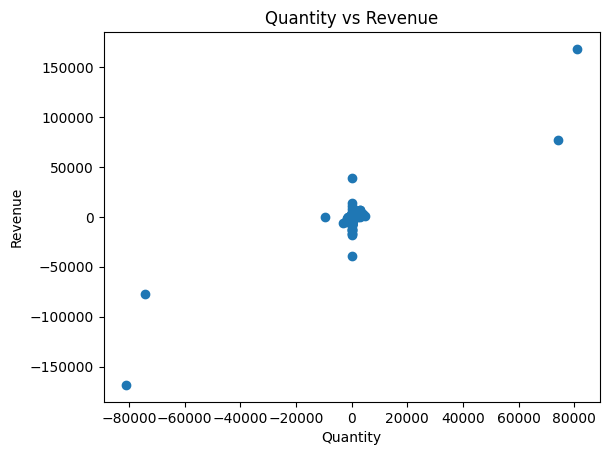

In [94]:
plt.figure()
plt.scatter(df['Quantity'], df['Revenue'])
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

In [95]:
#Basket Size vs Invoice Value
basket_size = df.groupby('InvoiceNo')['Quantity'].sum()
invoice_value = df.groupby('InvoiceNo')['Revenue'].sum()

In [96]:
basket_size.corr(invoice_value)

np.float64(0.8890309527774699)

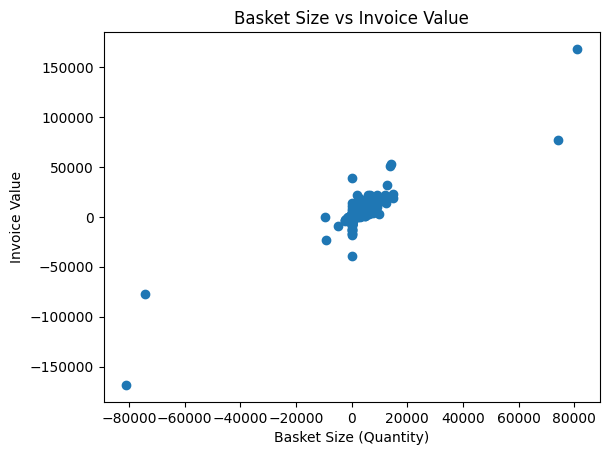

In [97]:
plt.figure()
plt.scatter(basket_size, invoice_value)
plt.title("Basket Size vs Invoice Value")
plt.xlabel("Basket Size (Quantity)")
plt.ylabel("Invoice Value")
plt.show()

In [98]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Day,DayName,Hour,Quarter,IsWeekend,BasketSize,UniqueProducts
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday,8,4,False,40,7
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,False,40,7
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday,8,4,False,40,7
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,False,40,7
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,False,40,7


In [99]:
cleaned_df = df.copy()

In [100]:
cleaned_df.to_csv("cleaned_data.csv")

In [101]:
cleaned_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month',
       'MonthName', 'Day', 'DayName', 'Hour', 'Quarter', 'IsWeekend',
       'BasketSize', 'UniqueProducts'],
      dtype='str')

In [102]:
df.info()

<class 'pandas.DataFrame'>
Index: 534129 entries, 0 to 541908
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   InvoiceNo       534129 non-null  str           
 1   StockCode       534129 non-null  str           
 2   Description     534129 non-null  str           
 3   Quantity        534129 non-null  int64         
 4   InvoiceDate     534129 non-null  datetime64[us]
 5   UnitPrice       534129 non-null  float64       
 6   CustomerID      534129 non-null  object        
 7   Country         534129 non-null  str           
 8   Revenue         534129 non-null  float64       
 9   Year            534129 non-null  int32         
 10  Month           534129 non-null  int32         
 11  MonthName       534129 non-null  str           
 12  Day             534129 non-null  int32         
 13  DayName         534129 non-null  str           
 14  Hour            534129 non-null  int32         
 15 

## 📊 Business Recommendations (Data-Driven Insights)

---

### 💰 Revenue Concentration Risk (UK Dependency)
- UK contributes ~84% of total revenue (8.18M out of 9.72M)
- Business is highly dependent on a single market

**Recommendations:**
- Diversify into Netherlands, EIRE, Germany, France  
- Launch region-specific marketing campaigns  
- Reduce over-dependence on UK market  

---

### 📈 Seasonal Sales Strategy
- Peak months: October, November, December  
- Low months: January, February, March  

**Recommendations:**
- Increase inventory before Q4 (Oct–Dec)  
- Run holiday bundles and festive promotions  
- Use Q1 for discounts and customer reactivation  

---

### 📦 Product Strategy
- Top products are mainly gift/home décor items  
- Revenue concentrated in few high-performing SKUs  

**Recommendations:**
- Expand gift and home décor product line  
- Create product bundles (e.g., retro gift packs)  
- Promote top products on homepage  

---

### 👥 Customer Behavior Insights
- Peak hours: 9 AM – 3 PM  
- Best day: Thursday  
- Weekend performance is weak (no Saturday sales observed)  

**Recommendations:**
- Focus marketing on weekdays (Tue–Thu)  
- Run campaigns during peak hours  
- Investigate missing Saturday sales (data/system issue)  

---

### 🌍 Country Expansion Strategy
- UK dominates revenue  
- Secondary markets: Netherlands, Germany, France, EIRE  

**Recommendations:**
- Scale marketing in strong EU countries  
- Localize campaigns for different regions  
- Reduce dependency on UK market  

---

### ⚡ Revenue Optimization
- Few products and countries generate majority of revenue  

**Recommendations:**
- Implement cross-selling and upselling strategies  
- Introduce bundle offers to increase basket size  
- Focus on high-value customers and products  

---

### ⚠️ Operational Insight
- No sales recorded on Saturday  

**Recommendation:**
- Verify data pipeline or business operating schedule  
- Ensure no missing transaction records  